# **Solemne 1 — Minería de Datos 2026**

# 1.- Obtencion de datos
## ¿qué espero encontrar?
En la tabla de 'health_nutrition_population' espero encontrar referencias a la salud nutricional de la poblacion en algun pais/ciudad especificado en la tabla.

In [119]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="yo-si-489418")

dataset_ref = client.dataset("world_bank_health_population", project="bigquery-public-data") #Dentro del la bigquery publica se busca el proyecto del banco mundial con salud

tables = list(client.list_tables(dataset_ref))

table_ref = dataset_ref.table("health_nutrition_population")

query = """
SELECT *
FROM `bigquery-public-data.world_bank_health_population.health_nutrition_population`
ORDER BY year DESC
"""


dry_run_config = bigquery.QueryJobConfig(dry_run=True)

dry_run_query_job = client.query(query, job_config=dry_run_config) #Estas lineas de codigo me mostraran cuando pesaran los datos que estare consultando.

print()
print("This query will process {} bytes.".format(dry_run_query_job.total_bytes_processed))



safe_config = bigquery.QueryJobConfig(maximum_bytes_billed=10**10) #Esto limita la cantidad de bytes que podria procesar (quizas no necesario pero no esta de mas)
query_job = client.query(query, job_config=safe_config)


Pandass = query_job.to_dataframe()       #transforma la query a un dataframe de pandas

Pandass

c:\Users\joshe\Documents\U weas\GIT\venv\Lib\site-packages\google\auth\_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)



This query will process 310099813 bytes.


,country_name,country_code,indicator_name,indicator_code,value,year
0,Belarus,BLR,"Population ages 70-74, male (% of male populat...",SP.POP.7074.MA.5Y,2.252892,2020
1,Other small states,OSS,"Population ages 05-09, female (% of female pop...",SP.POP.0509.FE.5Y,10.482102,2020
2,Vietnam,VNM,"Population ages 35-39, male",SP.POP.3539.MA,1.000000,2020
3,Indonesia,IDN,People with basic handwashing facilities inclu...,SH.STA.HYGN.ZS,94.107068,2020
4,New Zealand,NZL,"Population ages 05-09, male",SP.POP.0509.MA,1.000000,2020
...,...,...,...,...,...,...
3174991,Lesotho,LSO,"Age population, age 18, male, interpolated",SP.POP.AG18.MA.IN,1.000000,1960
3174992,Malaysia,MYS,"Age population, age 02, female, interpolated",SP.POP.AG02.FE.IN,1.000000,1960
3174993,Gibraltar,GIB,Rural population (% of total population),SP.RUR.TOTL.ZS,1.000000,1960
3174994,Mozambique,MOZ,"Age population, age 04, female, interpolated",SP.POP.AG04.FE.IN,1.000000,1960


# Limpieza y transformacion

---

Primero dare los datos pedidos como outpout de codigo sin filtrar y luego el filtrado de datos para trabajar de forma eficiente

In [120]:
print(f"Filas: {Pandass.shape[0]:,} | Columnas: {Pandass.shape[1]}")
print("Tipos:", ", ".join([f"{col}: {dtype}" for col, dtype in Pandass.dtypes.items()]))
print(f"Rango temporal: {Pandass['year'].min()} - {Pandass['year'].max()}")

nulos = Pandass.isnull().sum()
print("Nulos:", ", ".join([f"{col}: {val:,}" for col, val in nulos.items()]))


Filas: 3,174,996 | Columnas: 6
Tipos: country_name: object, country_code: object, indicator_name: object, indicator_code: object, value: float64, year: Int64
Rango temporal: 1960 - 2020
Nulos: country_name: 0, country_code: 0, indicator_name: 0, indicator_code: 0, value: 0, year: 0


---
Ahora hare un diccionario con los paises de latinoamerica para filtrar despues
, ya que este es un lugar mas cercano y mas de interes que paises de otro continente o que hablen otro idioma (por el entendimiento mas que nada)

In [121]:
latam = [
    'Argentina', 'Bolivia', 'Brasil', 'Chile', 'Colombia',
    'Costa Rica', 'Cuba', 'Ecuador', 'El Salvador', 'Guatemala',
    'Honduras', 'México', 'Nicaragua', 'Panamá', 'Paraguay',
    'Perú', 'República Dominicana', 'Uruguay', 'Venezuela'
]

Luego usare varios filtros y descartaremos algunas columnas, por ejemplo descartaremos 'country_code' y 'indicator_code' ya que esto no nos entrega datos relevantes para el analisis.

Tambien filtraremos los años, donde se veran los datos tomas entre los años 2000 y 2020, esto porque pienso que los datos atras del 2000 pueden verse afectados debido a la falta de tecnologia y concexion que pudo haber en años posteriores

In [122]:
Pandass_act = Pandass[['country_name', 'indicator_name', 'value', 'year']]
Pandass_act = Pandass_act[(Pandass_act['year'].between(2000, 2020) & Pandass_act['country_name'].isin(latam))]


print(Pandass_act['country_name'].unique())
print()
print(f"Filas: {Pandass_act.shape[0]:,} | Columnas: {Pandass_act.shape[1]}")
print("Tipos:", ", ".join([f"{col}: {dtype}" for col, dtype in Pandass_act.dtypes.items()]))
print(f"Rango temporal: {Pandass_act['year'].min()} - {Pandass_act['year'].max()}")

nulos = Pandass_act.isnull().sum()
print("Nulos:", ", ".join([f"{col}: {val:,}" for col, val in nulos.items()]))


['El Salvador' 'Ecuador' 'Guatemala' 'Nicaragua' 'Colombia' 'Argentina'
 'Bolivia' 'Cuba' 'Uruguay' 'Chile' 'Costa Rica' 'Honduras' 'Paraguay']

Filas: 84,879 | Columnas: 4
Tipos: country_name: object, indicator_name: object, value: float64, year: Int64
Rango temporal: 2000 - 2020
Nulos: country_name: 0, indicator_name: 0, value: 0, year: 0


Viendo estos datos los cuales fueron filtrado a datos mas actuales (Del 2000 en adelante) esto para tener una mayor fiabilidad en la compilacion de estos (tambien porque no existen nulos), espero que tengan una calidad decente para poder analisarlos de forma optima. Con un alcance directamente sobre la poblacion latinoamerica, donde busco la tasa de mortalidad en suicidios en hombres y mujeres., como la cantidad de filas no es tan grande podria ser que los datos a analizar no nos den una estadistica muy correcta.

---

Entonces ahora hare un filtro donde el las columnas 'indicator_name' tengan la palabra 'suicide'


In [123]:
suicidios = Pandass_act[(Pandass_act['indicator_name'].str.contains('Suicide mortality rate', case=False, na=False)) & 
                        (Pandass_act['indicator_name'].str.contains('male|female', case=False, na=False))]

#Uso todos estos datos para separar el termino suicidio dentro de la columna "indicator_name" y 'male,female' para filtrar los datos totales que hay

suicidios = suicidios.copy()            #me arrojaba un warning asi que con esto pude solucionarlo...

def normalizar(x):
    return (x - x.min()) / (x.max() - x.min())                  #funcion para normalizar los valores de la tabla

suicidios['valores_norma'] = suicidios.groupby('country_name')['value'].transform(normalizar)

suicidios = suicidios.sort_values(['country_name', 'year'])
suicidios

,country_name,indicator_name,value,year,valores_norma
1382616,Argentina,"Suicide mortality rate, male (per 100,000 male...",15.2,2000,0.893082
1386129,Argentina,"Suicide mortality rate, female (per 100,000 fe...",3.4,2000,0.150943
1292967,Argentina,"Suicide mortality rate, male (per 100,000 male...",16.9,2001,1.000000
1320232,Argentina,"Suicide mortality rate, female (per 100,000 fe...",1.0,2001,0.000000
1251564,Argentina,"Suicide mortality rate, male (per 100,000 male...",16.6,2002,0.981132
...,...,...,...,...,...
224978,Uruguay,"Suicide mortality rate, female (per 100,000 fe...",8.6,2017,0.225519
116243,Uruguay,"Suicide mortality rate, female (per 100,000 fe...",8.6,2018,0.225519
165786,Uruguay,"Suicide mortality rate, male (per 100,000 male...",34.7,2018,1.000000
70079,Uruguay,"Suicide mortality rate, male (per 100,000 male...",34.5,2019,0.994065


In [124]:
dic_paises = {}
for pais in suicidios["country_name"].unique():
    dic_paises[pais] = suicidios[suicidios["country_name"] == pais]
    print(f"{pais}: {len(dic_paises[pais])} filas")


Argentina: 40 filas
Bolivia: 40 filas
Chile: 40 filas
Colombia: 40 filas
Costa Rica: 40 filas
Cuba: 40 filas
Ecuador: 40 filas
El Salvador: 40 filas
Guatemala: 40 filas
Honduras: 40 filas
Nicaragua: 40 filas
Paraguay: 40 filas
Uruguay: 40 filas


---

# Analisis exploratorio (EDA)


In [125]:
#Estadisticas descriptivas
stats_suicid = suicidios.groupby('country_name')['value'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)

# Rango = max - min
stats_suicid['rangos'] = stats_suicid['max'] - stats_suicid['min']

print(stats_suicid)

               mean  median    std  min   max  rangos
country_name                                         
Argentina      8.63    4.00   5.84  1.0  16.9    15.9
Bolivia        5.71    4.50   2.26  1.0   8.8     7.8
Chile          9.42    4.30   7.31  1.0  20.6    19.6
Colombia       4.22    4.25   2.45  1.0   7.6     6.6
Costa Rica     6.04    2.50   4.91  1.0  14.1    13.1
Cuba          12.27    7.60   8.53  1.0  24.6    23.6
Ecuador        7.60    5.60   4.72  1.0  15.4    14.4
El Salvador    6.40    3.35   4.64  1.0  15.3    14.3
Guatemala      6.83    3.85   5.55  1.0  18.2    17.2
Honduras       2.36    2.00   1.77  0.8   7.2     6.4
Nicaragua      4.53    3.10   2.67  1.0   8.2     7.2
Paraguay       4.24    3.45   2.14  1.0   8.7     7.7
Uruguay       16.87    9.25  10.77  1.0  34.7    33.7


## Primera regunta

Al estar observando los datos en un principio, y tambien la principal razon por la que elegi estos filtros anteriores, es la tasa de mortalidad en suicidios presentados en las tablas.

Entonces esta pregunta va dirigida a ¿como ha ido evolucionando esta tasa de suicidio a lo largo del tiempo? ¿habrá aumentado con los años? 

---

## Segunda pregunta

Otro dato interesante a ponerle atencion son los promedios ('mean') que habla de lo variable que puede ser entre paises, donde algunos presentan tasas de alta de suicidio mientras que otras con valores bajos, o tambien ponerle atencion a los rangos que nos diran los peores periodos.

Esto me puede hacer pensar que la situacion de cada pais pueda llevar a tener una tasa de suicidios que acaban en mortalidad aumente o disminuya, entonces una buena pregunta seria ¿Cuales son los periodos con mas mortalidad de los paises? ¿esto se debe a un periodo dificil de un pais o se debera a otra variable? (esto incluyendo la parte de la temporaridad)

---

# Visualizaciones



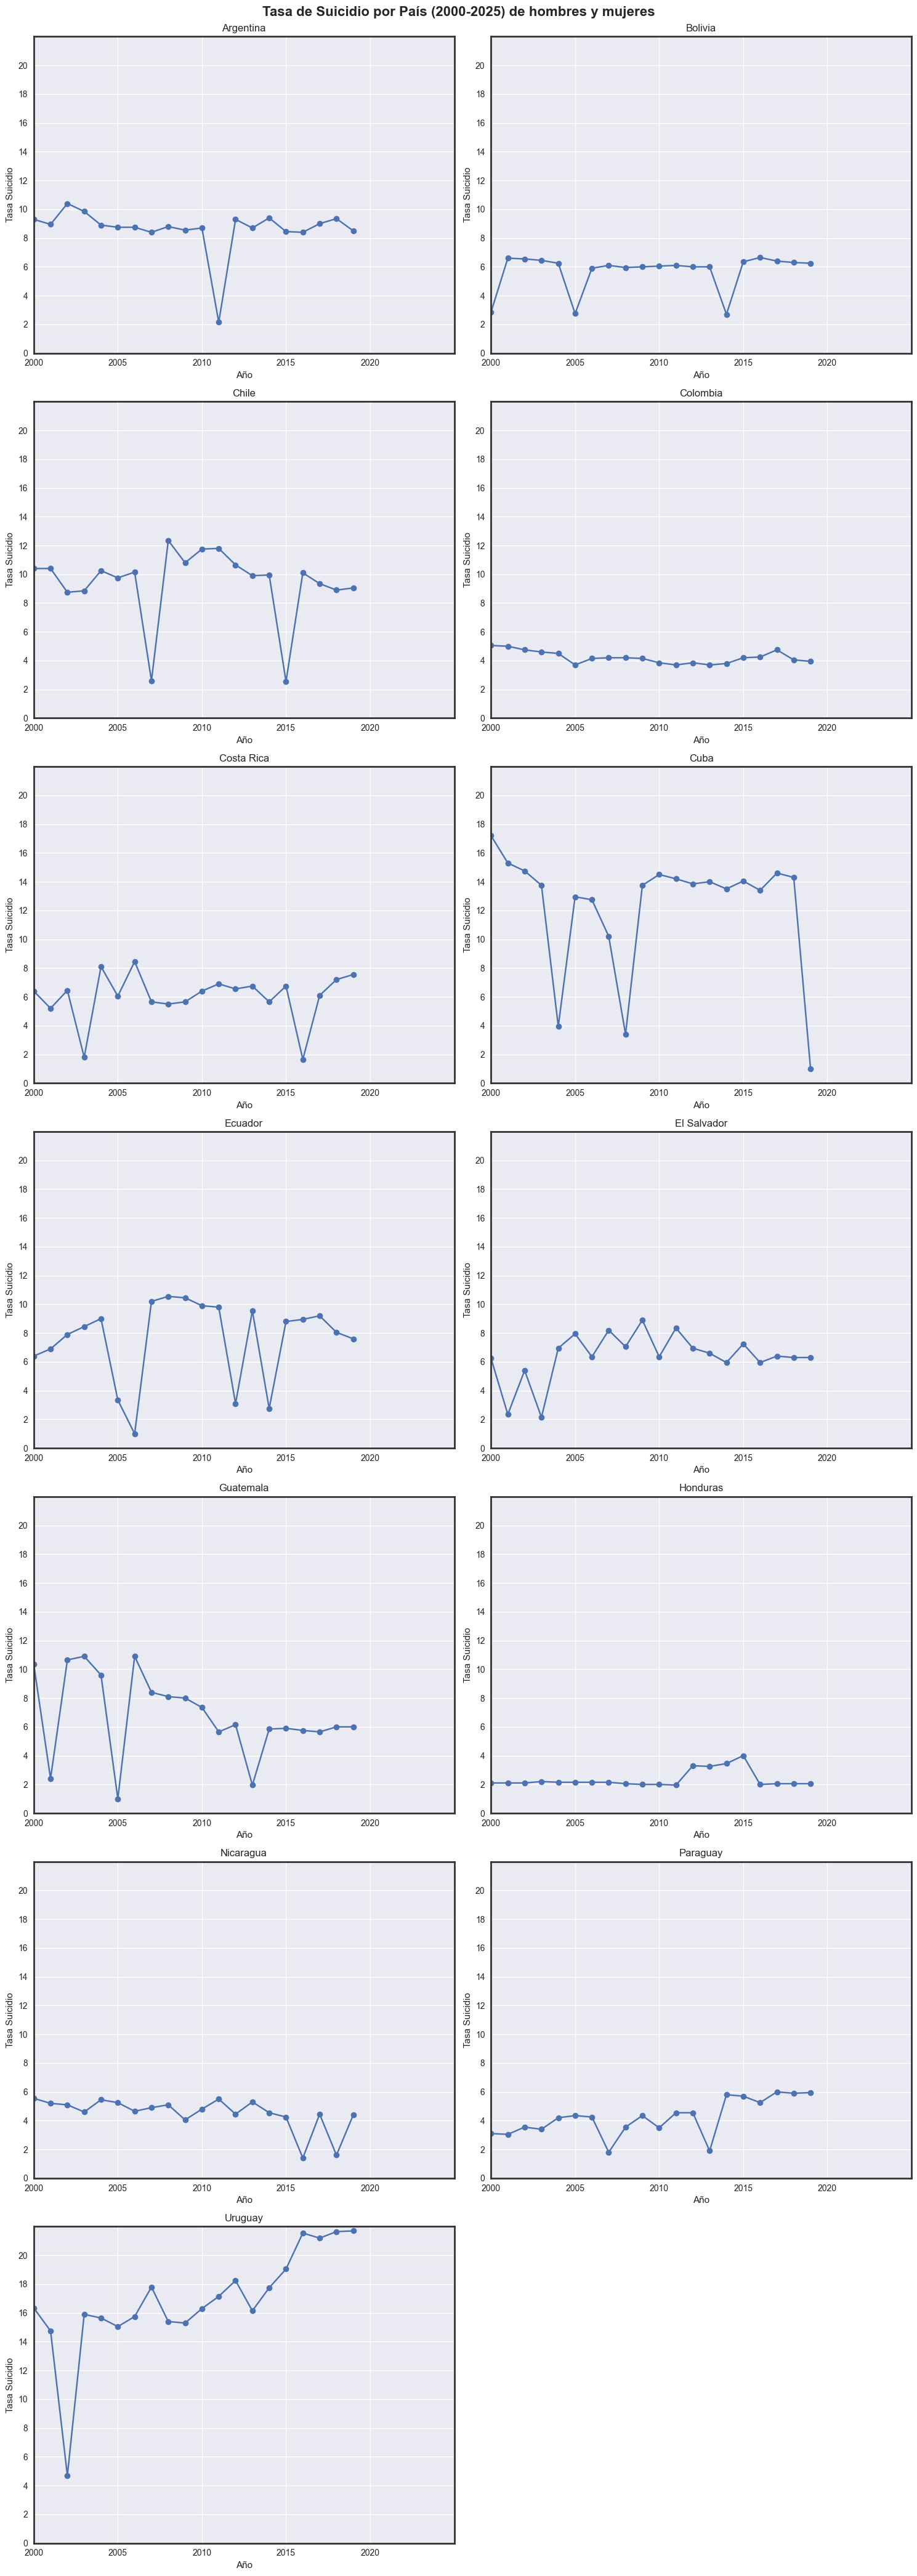

In [144]:
import matplotlib.pyplot as plt
import seaborn as sea

plt.style.use('seaborn-v0_8')  #estilo mas bonito

grafics_paises = list(dic_paises.keys()) #Esta linea me hace extraer los nombres de paises en mi diccionario
n = len(grafics_paises)

column = 2
filas = (n + column -1) // column       #calculo de columnas

fig, axes = plt.subplots(filas, column, figsize=(15, 6 * filas))
plt.subplots_adjust(top=0.90, bottom=0.08, hspace=0.4)
axes = axes.flatten()

for i, pais in enumerate(grafics_paises):
    graph = dic_paises[pais].sort_values('year')
    graph = graph.groupby('year')['value'].mean().reset_index()
    
    axes[i].plot(graph['year'], graph['value'], marker='o')
    axes[i].set_title(pais)
    axes[i].set_xlabel('Año')
    axes[i].set_ylabel('Tasa Suicidio')
    axes[i].grid(True)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

for ax in axes[:len(grafics_paises)]:  
    ax.set_xlim(2000, 2025)    
    ax.set_ylim(0, 22)           
    ax.set_xticks(range(2000, 2025, 5))  
    ax.set_yticks(range(0, 22, 2))   

fig.suptitle('Tasa de Suicidio por País (2000-2025) de hombres y mujeres', fontsize=16, fontweight='bold', y=0.995)

plt.grid(True)
plt.subplots_adjust(wspace=0.35, hspace=0.35)
for ax in axes[:len(grafics_paises)]:
    for spine in ax.spines.values():
        spine.set_linewidth(2) 
        spine.set_color('#333')
plt.tight_layout()

plt.show()

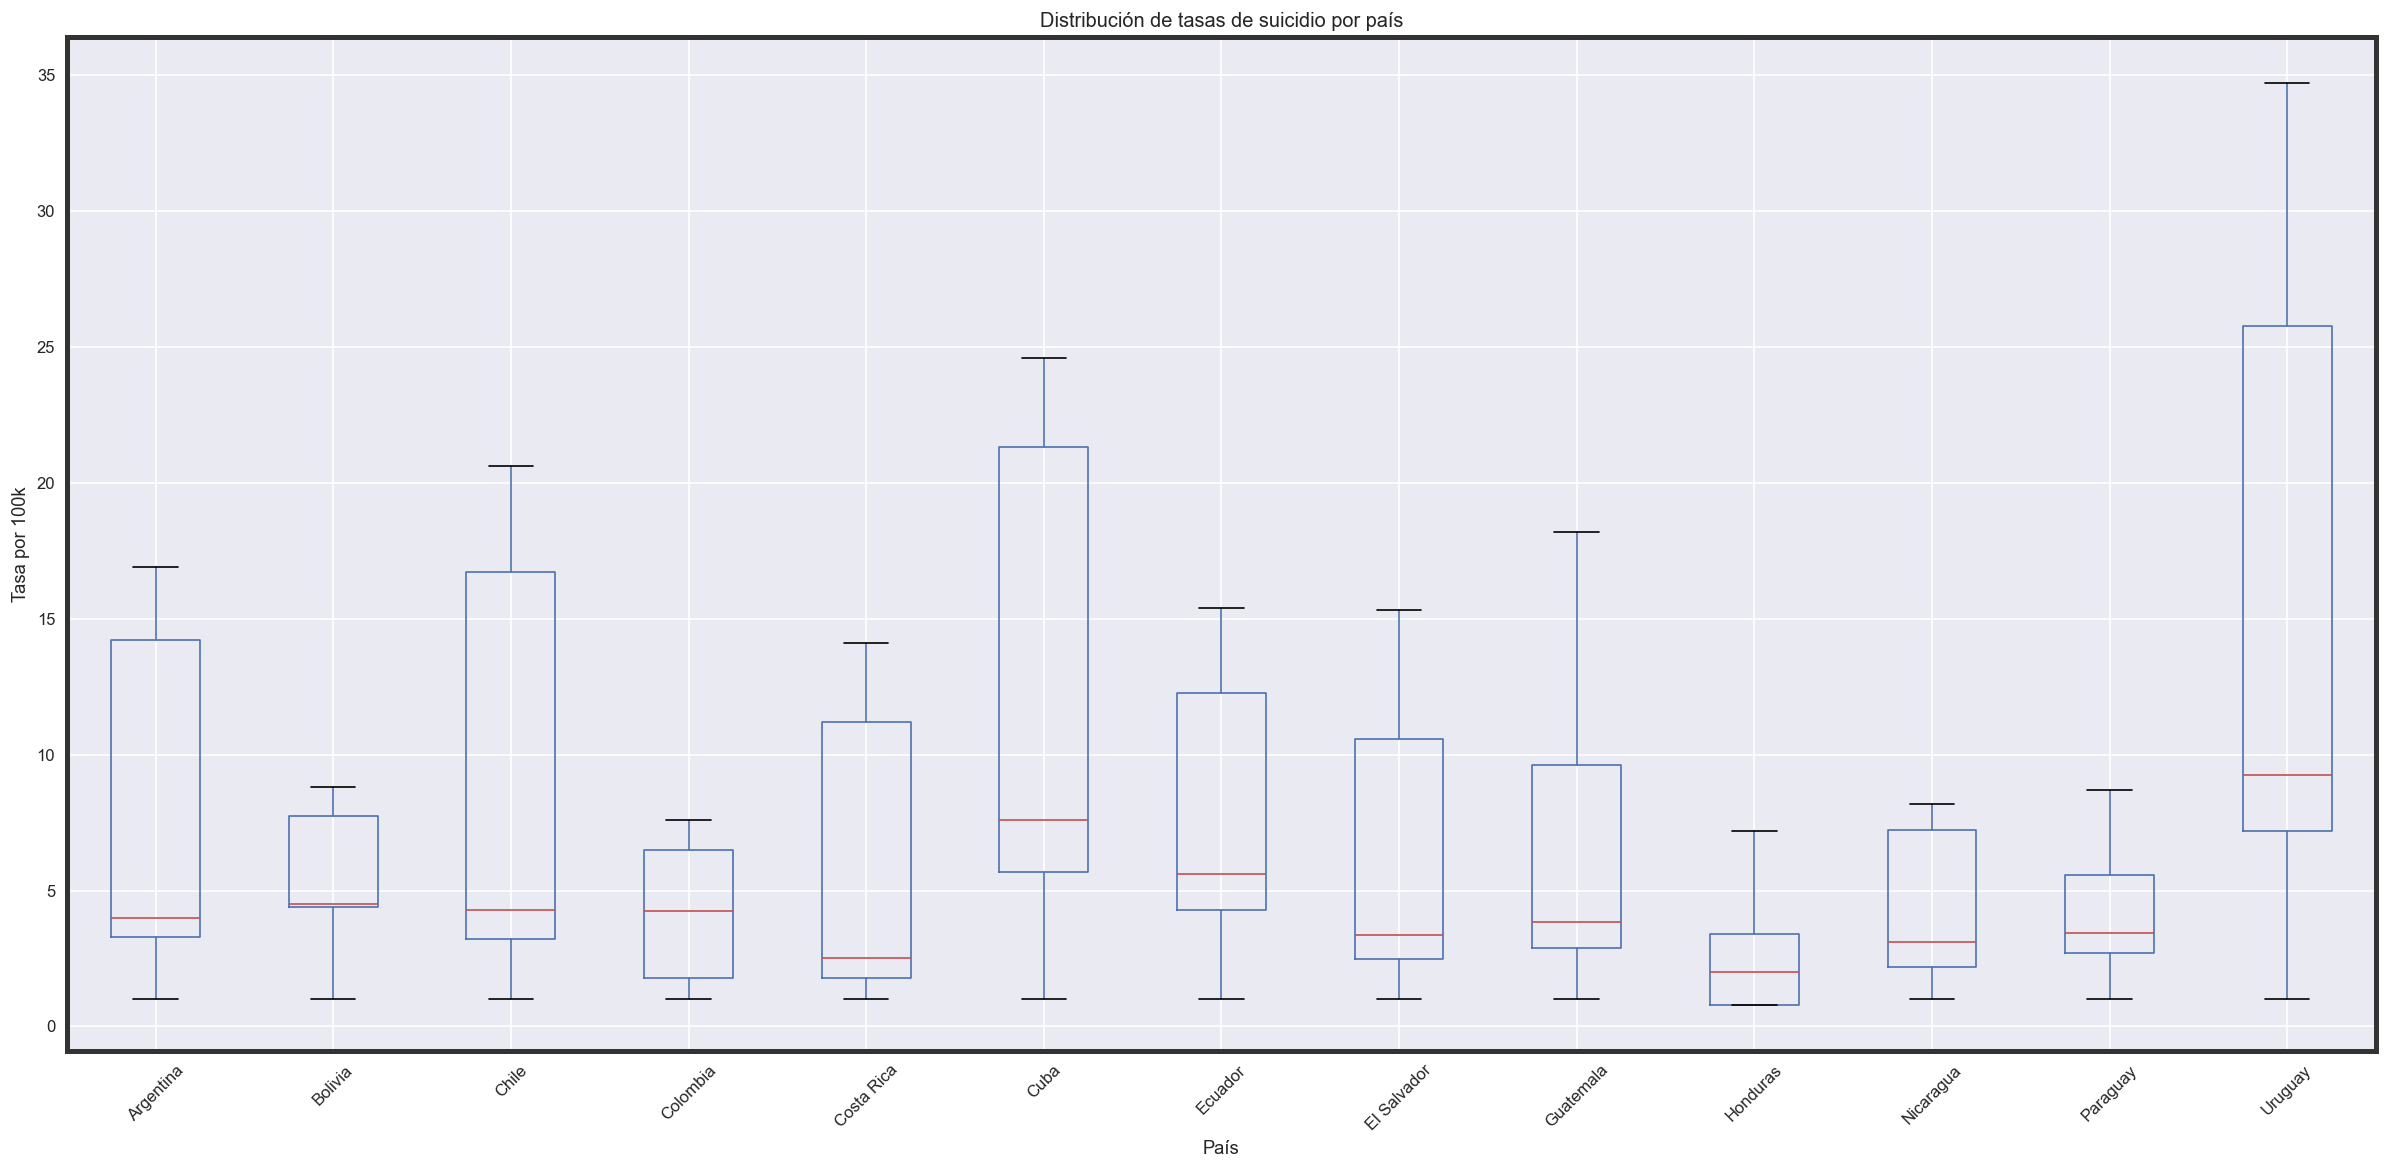

In [145]:
plt.style.use('seaborn-v0_8')

comparacion = ['Honduras', 'Colombia', 'Paraguay', 'Nicaragua', 'Bolivia', 'El Salvador', 'Costa Rica', 'Ecuador', 'Guatemala', 'Argentina', 'Chile', 'Cuba', 'Uruguay']
comp = suicidios[suicidios['country_name'].isin(comparacion)]

promedio = comp.groupby('country_name')['value'].agg(['mean', 'median']).reset_index()
fig, ax = plt.subplots(figsize=(20,10), dpi=120)

comp.boxplot(column='value', by='country_name', ax=ax)


plt.title('Distribución de tasas de suicidio por país')
plt.suptitle('')  
plt.xlabel('País')
plt.ylabel('Tasa por 100k')
plt.xticks(rotation=45)
for spine in ax.spines.values():
    spine.set_linewidth(3)
    spine.set_color('#333')

plt.tight_layout()
plt.show()

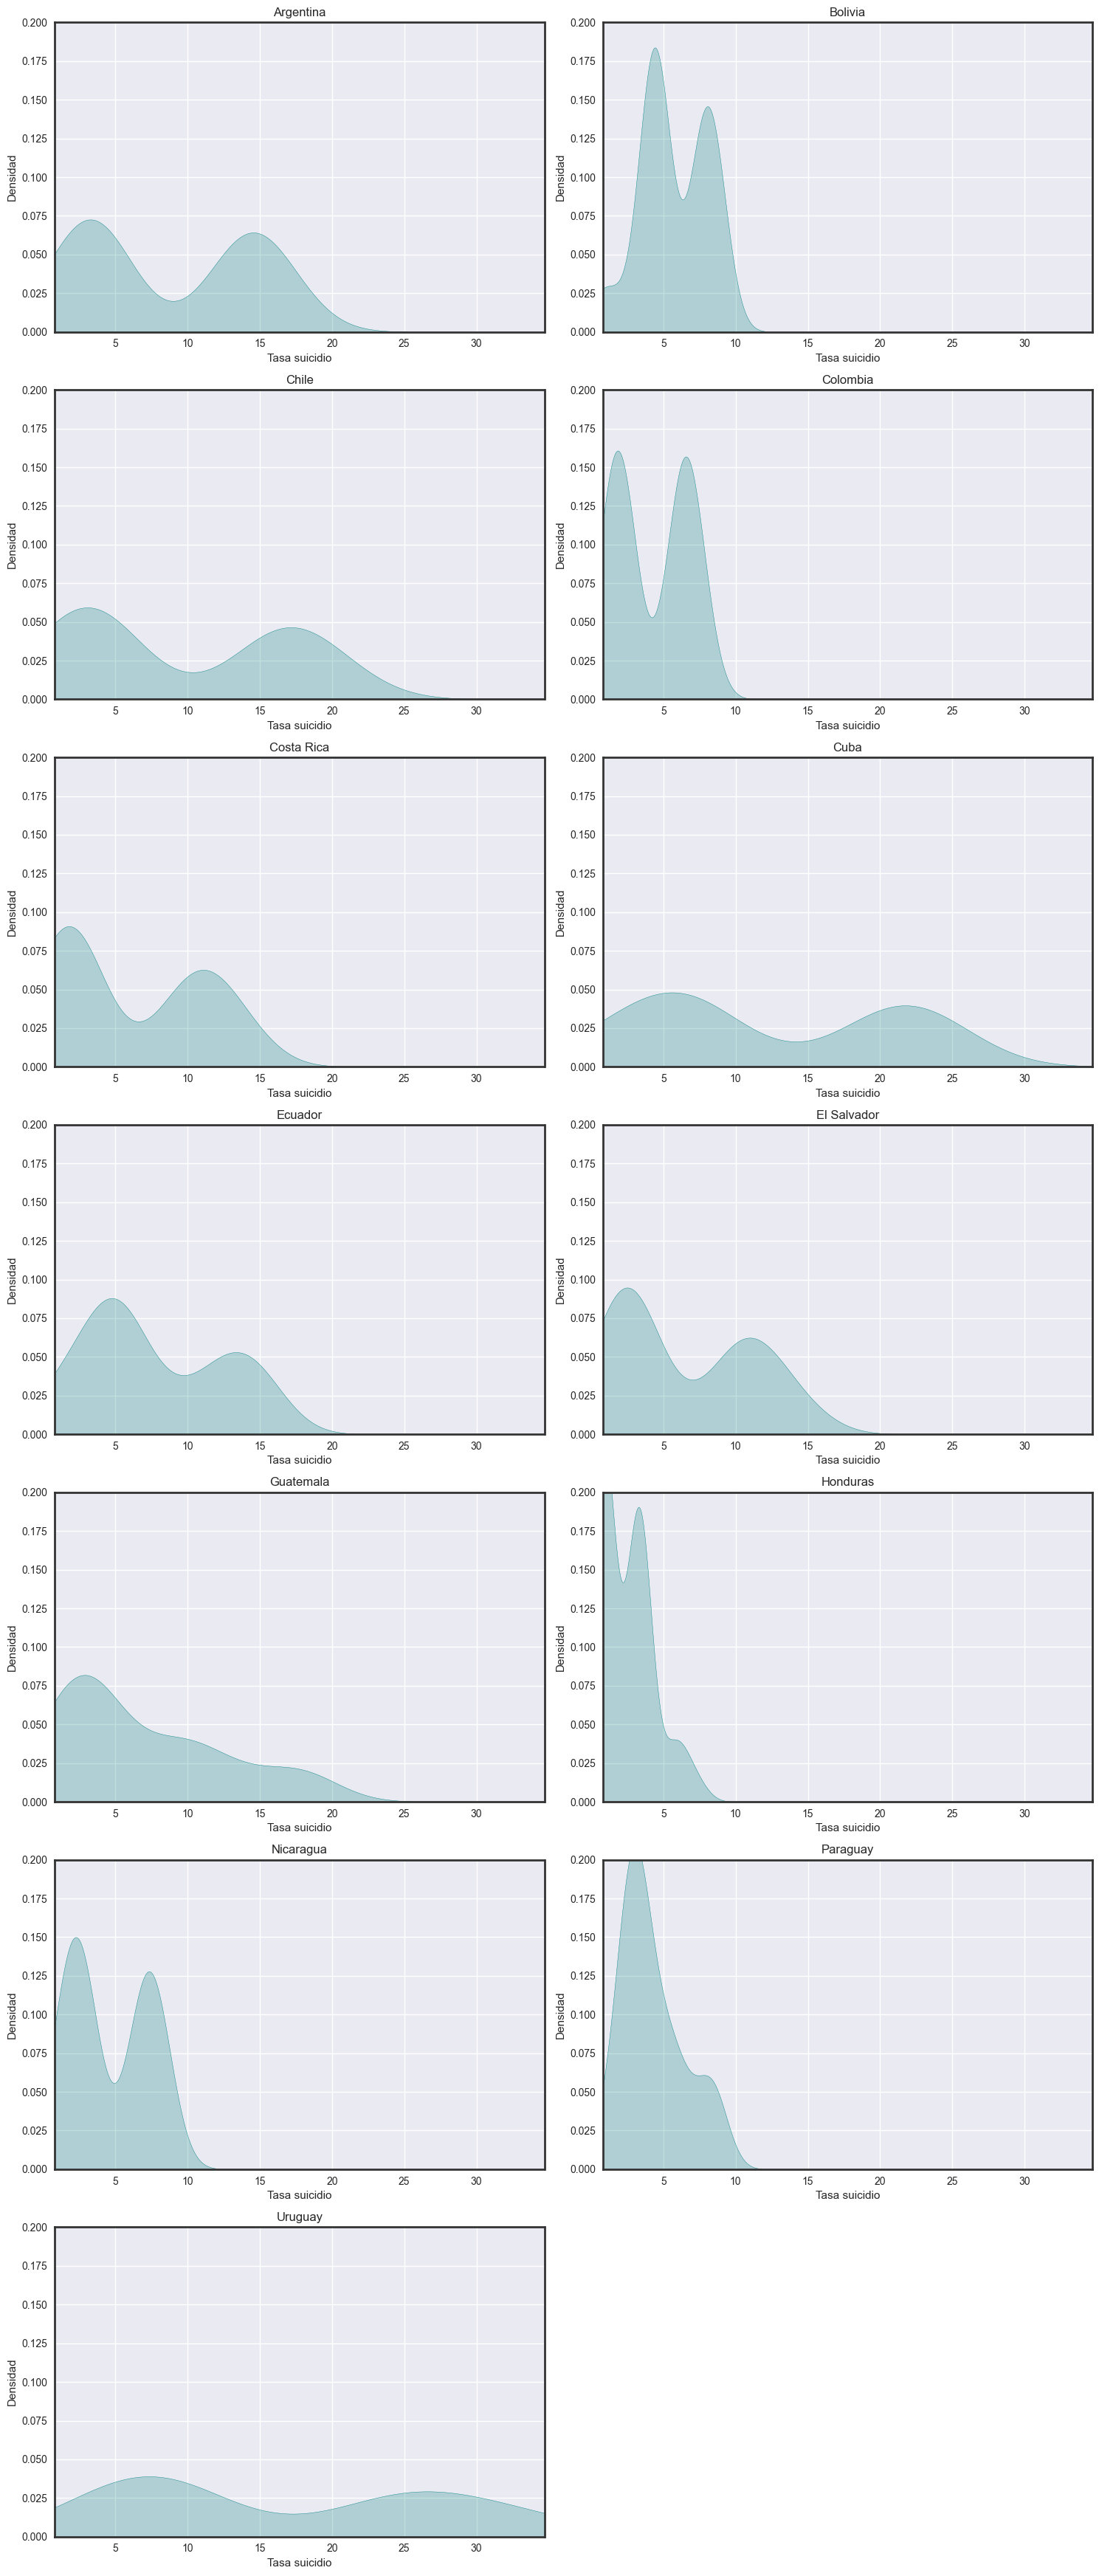

In [147]:
plt.style.use('seaborn-v0_8')  #estilo mas bonito

grafics_paises_kde = list(dic_paises.keys()) #Esta linea me hace extraer los nombres de paises en mi diccionario
n = len(grafics_paises_kde)

xmin = suicidios['value'].min()
xmax = suicidios['value'].max()
column = 2
filas = (n + column -1) // column       #calculo de columnas

fig, axes = plt.subplots(filas, column, figsize=(15, 5 * filas))
axes = axes.flatten()

for i, pais in enumerate(grafics_paises_kde):
    kde = suicidios[suicidios['country_name'] == pais]
    

    sea.kdeplot(data=kde, x='value', ax=axes[i], fill=True, color='teal')
    axes[i].set_title(f'{pais}', fontsize=12)
    axes[i].set_xlabel('Tasa suicidio')
    axes[i].set_ylabel('Densidad')
    axes[i].set_xlim(xmin, xmax)
    axes[i].set_ylim(0, 0.2)


# Quitar subplots vacíos
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
    
plt.subplots_adjust(wspace=0.35, hspace=0.35)
for ax in axes[:len(grafics_paises)]:
    for spine in ax.spines.values():
        spine.set_linewidth(2) 
        spine.set_color('#333')

plt.tight_layout()
plt.show()


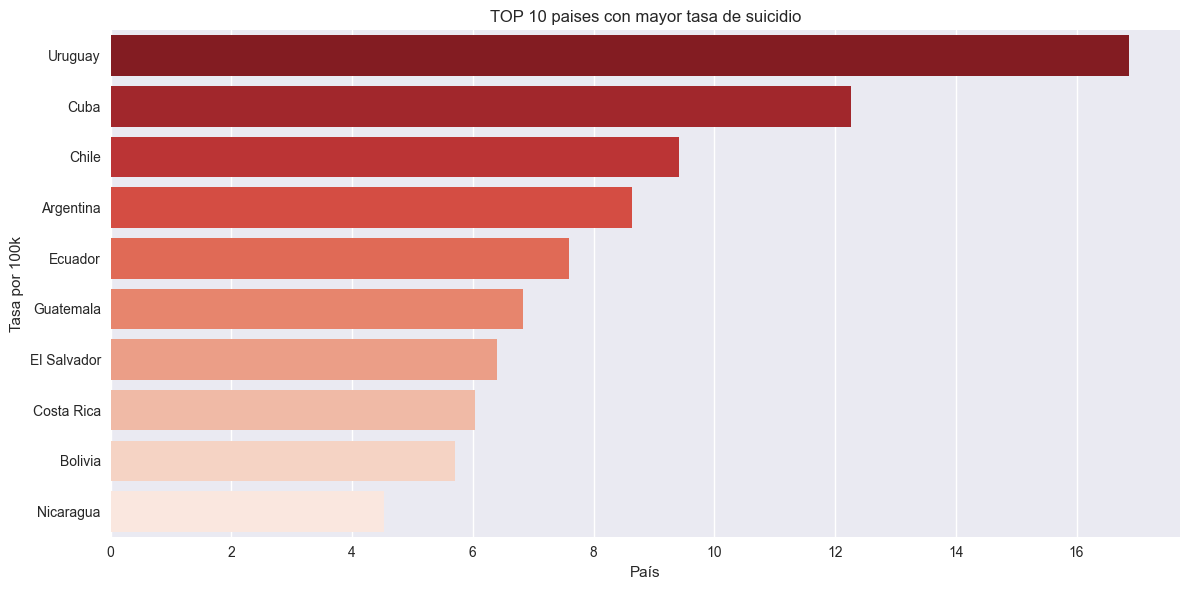

In [ ]:
top10 = suicidios.groupby('country_name')['value'].mean().nlargest(10).reset_index()


plt.figure(figsize=(12, 6))
sea.barplot(data=top10, y='country_name', x='value', hue='country_name', palette='Reds_r', legend=False)

plt.title('TOP 10 paises con mayor tasa de suicidio')
plt.xlabel('País')
plt.ylabel('Tasa por 100k')


plt.tight_layout()
plt.show()